# Task 2: Exploratory Data Analysis

In [1]:
!pip install -U transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.7/520.7 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.3 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling trans

In [22]:
# Add/merge into imports cell
import re, html, random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, precision_score, recall_score


In [3]:
! mkdir -p data

# Download train/dev split file (practice split)
! wget -O data/practice_splits.zip \https://github.com/Perez-AlmendrosC/dontpatronizeme/archive/refs/heads/master.zip

# Download test set (raw TSV)
! wget -O data/task4_test.tsv \https://raw.githubusercontent.com/Perez-AlmendrosC/dontpatronizeme/master/semeval-2022/TEST/task4_test.tsv

# Download dataset
! wget -O data/dontpatronizeme_pcl.tsv \https://raw.githubusercontent.com/CRLala/NLPLabs-2024/refs/heads/main/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv

# Unzip the dataset
!unzip data/practice_splits.zip -d data/

--2026-03-03 23:30:28--  https://github.com/Perez-AlmendrosC/dontpatronizeme/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/Perez-AlmendrosC/dontpatronizeme/zip/refs/heads/master [following]
--2026-03-03 23:30:29--  https://codeload.github.com/Perez-AlmendrosC/dontpatronizeme/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.112.10
Connecting to codeload.github.com (codeload.github.com)|140.82.112.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘data/practice_splits.zip’

data/practice_split     [  <=>               ] 664.12K  2.19MB/s    in 0.3s    

2026-03-03 23:30:29 (2.19 MB/s) - ‘data/practice_splits.zip’ saved [680064]

--2026-03-03 23:30:29--  https://raw.githubusercontent.com/Perez-Almen

In [4]:
import pandas as pd

# 1) Load the PCL Dataset TSV
full_df = pd.read_csv(
    "data/dontpatronizeme_pcl.tsv",
    sep="\t",
    skiprows=3, # disclaimer is lines 1–3, data starts at line 4
    header=None
)

# Assign column names
full_df.columns = ["par_id", "art_id", "keyword", "country_code", "text", "label"]

# 2) Convert graded label (0–4) -> binary (0/1) using {0,1}=NoPCL and {2,3,4}=PCL
full_df["label"] = full_df["label"].astype(int)
full_df["label_bin"] = (full_df["label"] >= 2).astype(int)

# 3) Load split IDs
train_ids = pd.read_csv("data/dontpatronizeme-master/semeval-2022/practice splits/train_semeval_parids-labels.csv")
dev_ids   = pd.read_csv("data/dontpatronizeme-master/semeval-2022/practice splits/dev_semeval_parids-labels.csv")

# 4) Ensure types match
full_df["par_id"] = full_df["par_id"].astype(int)
train_ids["par_id"] = train_ids["par_id"].astype(int)
dev_ids["par_id"] = dev_ids["par_id"].astype(int)

# 5) Merge to get actual train/dev dataframes
train_df = full_df.merge(train_ids[["par_id"]], on="par_id", how="inner")
dev_df   = full_df.merge(dev_ids[["par_id"]], on="par_id", how="inner")

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("\nTrain label distribution:\n", train_df["label_bin"].value_counts())

Train shape: (8375, 7)
Dev shape: (2094, 7)

Train label distribution:
 label_bin
0    7581
1     794
Name: count, dtype: int64


##: Technique 1: Basic Statistical Profiling

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

In [6]:
# Simple tokeniser. Lowercase and keep simple apostrophes, ignore punctuation
def simple_tokenize(text: str):
  return re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?", str(text).lower())

### Token Count: Sentence Length Statistics


=== TRAIN: Length Stats (token_count_tok) ===


,mean,median,min,max,p95,p99
0,43.40597,38.0,1,819,92.0,127.0



=== DEV: Length Stats (token_count_tok) ===


,mean,median,min,max,p95,p99
0,42.344795,37.0,1,259,89.0,128.07


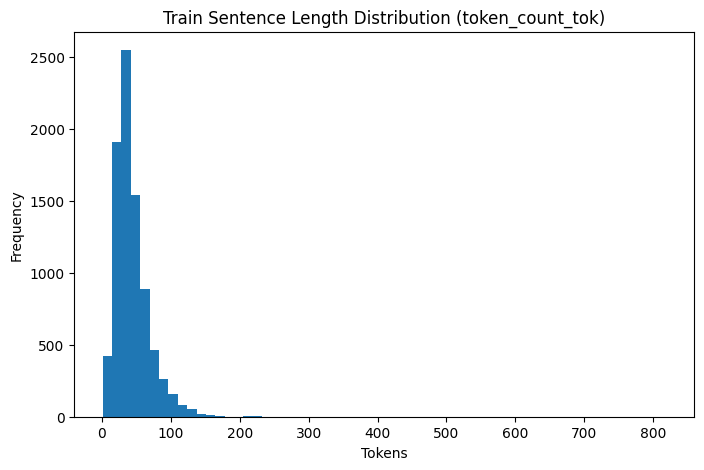

<Figure size 600x400 with 0 Axes>

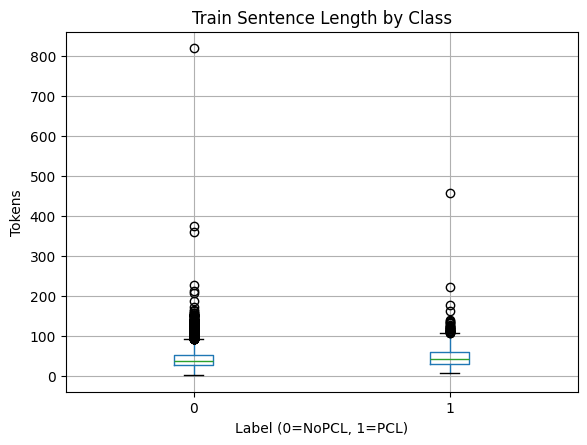


=== TRAIN: Length Summary by Class ===


,count,mean,std,min,25%,50%,75%,max
label_bin,,,,,,,,
0,7581.0,42.943411,26.043916,1.0,27.0,37.0,53.0,819.0
1,794.0,47.822418,30.222211,6.0,29.0,41.0,60.0,457.0


In [7]:
# -----------------------------
# 1) Sentence length stats (token count)
# -----------------------------
def add_length_cols(df, text_col="text"):
    df = df.copy()
    df["token_count_ws"] = df[text_col].astype(str).apply(lambda x: len(x.split()))
    df["token_count_tok"] = df[text_col].astype(str).apply(lambda x: len(simple_tokenize(x)))
    return df

train_prof = add_length_cols(train_df)
dev_prof   = add_length_cols(dev_df)

def length_stats(df, length_col="token_count_tok", name="TRAIN"):
    arr = df[length_col].to_numpy()
    stats = {
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "min": int(np.min(arr)),
        "max": int(np.max(arr)),
        "p95": float(np.percentile(arr, 95)),
        "p99": float(np.percentile(arr, 99)),
    }
    print(f"\n=== {name}: Length Stats ({length_col}) ===")
    display(pd.DataFrame([stats]))
    return stats

train_len_stats = length_stats(train_prof, name="TRAIN")
dev_len_stats   = length_stats(dev_prof, name="DEV")

# Visual: length distribution
plt.figure(figsize=(8,5))
plt.hist(train_prof["token_count_tok"], bins=60)
plt.title("Train Sentence Length Distribution (token_count_tok)")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()

# Per-class length comparison (boxplot)
plt.figure(figsize=(6,4))
train_prof.boxplot(column="token_count_tok", by="label_bin")
plt.title("Train Sentence Length by Class")
plt.suptitle("")
plt.xlabel("Label (0=NoPCL, 1=PCL)")
plt.ylabel("Tokens")
plt.show()

# Tabular per-class length summary (good for report)
print("\n=== TRAIN: Length Summary by Class ===")
display(train_prof.groupby("label_bin")["token_count_tok"].describe())

In [8]:
# -----------------------------
# 2) Vocabulary size + rare word proportion (train only)
# -----------------------------
all_tokens = []
for t in train_df["text"].astype(str):
    all_tokens.extend(simple_tokenize(t))

vocab = set(all_tokens)
counts = Counter(all_tokens)
rare_1 = sum(1 for w, c in counts.items() if c == 1)
rare_5 = sum(1 for w, c in counts.items() if c < 5)

vocab_tbl = pd.DataFrame([{
    "total_tokens": len(all_tokens),
    "vocab_size": len(vocab),
    "hapax_count(freq=1)": rare_1,
    "hapax_prop": rare_1 / max(len(vocab), 1),
    "rare_<5_count": rare_5,
    "rare_<5_prop": rare_5 / max(len(vocab), 1),
}])

print("\n=== TRAIN: Vocabulary / Sparsity ===")
display(vocab_tbl)


=== TRAIN: Vocabulary / Sparsity ===


,total_tokens,vocab_size,hapax_count(freq=1),hapax_prop,rare_<5_count,rare_<5_prop
0,363525,26073,12726,0.488091,19808,0.759713



=== TRAIN: Class Distribution ===


,count,proportion
label_bin,,
0,7581,0.9052
1,794,0.0948



=== DEV: Class Distribution ===


,count,proportion
label_bin,,
0,1895,0.905
1,199,0.095


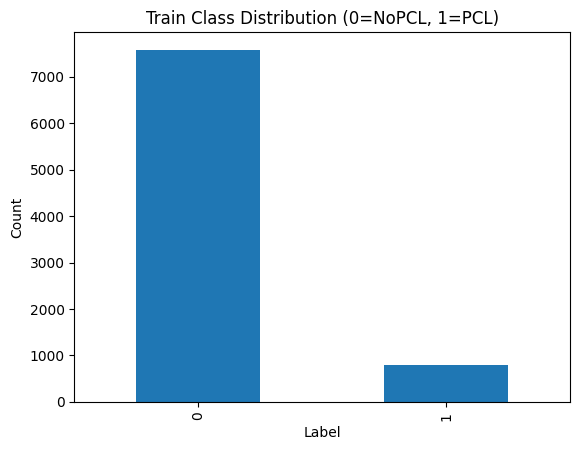

In [9]:
# -----------------------------
# 3) Class distribution
# -----------------------------
def class_profile(df, label_col="label_bin", name="TRAIN"):
    counts = df[label_col].value_counts().sort_index()
    props = (counts / counts.sum()).round(4)
    out = pd.DataFrame({"count": counts, "proportion": props})
    print(f"\n=== {name}: Class Distribution ===")
    display(out)
    return out

train_class_tbl = class_profile(train_df, name="TRAIN")
dev_class_tbl   = class_profile(dev_df, name="DEV")

plt.figure()
train_df["label_bin"].value_counts().sort_index().plot(kind="bar")
plt.title("Train Class Distribution (0=NoPCL, 1=PCL)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## Class-Specific Lexical Analaysis
### (Discriminative Word Patterns)

This would be an ideal method for PCL detection since the task is detecting patronising/ condescending language, allowing us to identify linguistic patterns.

In [10]:
def top_words_by_class(df, label, text_col="text", label_col="label_bin", k=20):
    tokens = []
    for t in df.loc[df[label_col] == label, text_col].astype(str):
        tokens.extend(simple_tokenize(t))
    return Counter(tokens).most_common(k)

top0 = top_words_by_class(train_df, 0, k=20)  # No PCL
top1 = top_words_by_class(train_df, 1, k=20)  # PCL

top0_df = pd.DataFrame(top0, columns=["word", "count"])
top1_df = pd.DataFrame(top1, columns=["word", "count"])

print("Top words: No PCL (label=0)")
display(top0_df)

print("Top words: PCL (label=1)")
display(top1_df)

Top words: No PCL (label=0)


,word,count
0,the,18720
1,to,10128
2,of,9997
3,and,9069
4,in,8009
5,a,6550
6,for,3515
7,that,3496
8,is,3211
9,s,2545


Top words: PCL (label=1)


,word,count
0,the,2140
1,to,1317
2,and,1234
3,of,1228
4,in,841
5,a,807
6,for,429
7,is,419
8,that,402
9,are,334


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Keep it simple + interpretable
vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"[A-Za-z]+(?:'[A-Za-z]+)?",
    min_df=5,           # ignore extremely rare noise
    max_df=0.9,         # ignore almost-always words
    ngram_range=(1,1)   # unigrams for clarity
)

X = vectorizer.fit_transform(train_df["text"].astype(str))
y = train_df["label_bin"].astype(int).to_numpy()
vocab = np.array(vectorizer.get_feature_names_out())

# mean tf-idf per class
mean0 = X[y==0].mean(axis=0).A1
mean1 = X[y==1].mean(axis=0).A1

diff = mean1 - mean0  # positive => more associated with PCL
top_pos_idx = np.argsort(diff)[-20:][::-1]
top_neg_idx = np.argsort(diff)[:20]

pcl_terms = pd.DataFrame({
    "term": vocab[top_pos_idx],
    "mean_tfidf_PCL": mean1[top_pos_idx],
    "mean_tfidf_NoPCL": mean0[top_pos_idx],
    "diff(PCL-NoPCL)": diff[top_pos_idx]
})

nopcl_terms = pd.DataFrame({
    "term": vocab[top_neg_idx],
    "mean_tfidf_PCL": mean1[top_neg_idx],
    "mean_tfidf_NoPCL": mean0[top_neg_idx],
    "diff(PCL-NoPCL)": diff[top_neg_idx]
})

print("Most discriminative terms for PCL (higher mean TF-IDF in PCL)")
display(pcl_terms)

print("Most discriminative terms for No PCL (higher mean TF-IDF in No PCL)")
display(nopcl_terms)

Most discriminative terms for PCL (higher mean TF-IDF in PCL)


,term,mean_tfidf_PCL,mean_tfidf_NoPCL,diff(PCL-NoPCL)
0,need,0.025541,0.012836,0.012706
1,and,0.063528,0.051039,0.012489
2,help,0.017915,0.005597,0.012318
3,children,0.022137,0.010115,0.012022
4,to,0.068208,0.056204,0.012004
5,hope,0.013718,0.001845,0.011872
6,poor,0.023364,0.011500,0.011864
7,we,0.024660,0.012899,0.011761
8,our,0.018326,0.006743,0.011583
9,homeless,0.022887,0.011852,0.011035


Most discriminative terms for No PCL (higher mean TF-IDF in No PCL)


,term,mean_tfidf_PCL,mean_tfidf_NoPCL,diff(PCL-NoPCL)
0,immigrants,0.004629,0.014928,-0.010298
1,illegal,0.000919,0.007291,-0.006373
2,immigrant,0.001514,0.007746,-0.006232
3,were,0.009002,0.014192,-0.005190
4,migrants,0.002616,0.007042,-0.004425
5,s,0.020252,0.024633,-0.004381
6,trump,0.001539,0.005333,-0.003794
7,workers,0.000786,0.004480,-0.003694
8,on,0.019639,0.023292,-0.003653
9,its,0.004181,0.007802,-0.003621


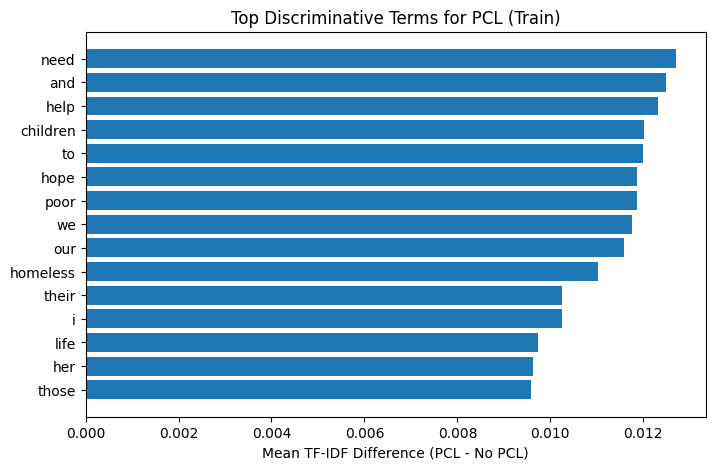

In [12]:
# Plot top 15 PCL-associated terms
plot_df = pcl_terms.head(15).iloc[::-1]  # reverse for nicer barh ordering

plt.figure(figsize=(8,5))
plt.barh(plot_df["term"], plot_df["diff(PCL-NoPCL)"])
plt.xlabel("Mean TF-IDF Difference (PCL - No PCL)")
plt.title("Top Discriminative Terms for PCL (Train)")
plt.show()

# Task 3: RoBERTa Baseline Model

In [23]:
def clean_text(s: str) -> str:
    s = str(s)
    s = html.unescape(s)                 # decode &amp; etc.
    s = re.sub(r"<[^>]+>", " ", s)       # remove HTML tags
    s = re.sub(r"([!?.,])\1{2,}", r"\1", s)  # collapse repeated punctuation
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_df = train_df.copy()
dev_df = dev_df.copy()

train_df["text"] = train_df["text"].fillna("").astype(str)
dev_df["text"]   = dev_df["text"].fillna("").astype(str)

train_df["label_bin"] = train_df["label_bin"].astype(int)
dev_df["label_bin"]   = dev_df["label_bin"].astype(int)

In [24]:
# Build HF datasets from the DataFrames
from datasets import Dataset

train_hf = Dataset.from_pandas(train_df[["text", "label_bin"]].copy())
dev_hf   = Dataset.from_pandas(dev_df[["text", "label_bin"]].copy())

train_hf = train_hf.rename_column("label_bin", "labels")
dev_hf   = dev_hf.rename_column("label_bin", "labels")

In [25]:
checkpoint = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=True)

MAX_LEN = 128

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_hf = Dataset.from_pandas(train_df[["text", "label_bin"]].copy()).rename_column("label_bin", "labels")
dev_hf   = Dataset.from_pandas(dev_df[["text", "label_bin"]].copy()).rename_column("label_bin", "labels")

train_hf = train_hf.map(tokenize, batched=True)
dev_hf   = dev_hf.map(tokenize, batched=True)

cols = ["input_ids", "attention_mask", "labels"]
train_hf.set_format(type="torch", columns=cols)
dev_hf.set_format(type="torch", columns=cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, pad_to_multiple_of=8)

Map:   0%|          | 0/8375 [00:00<?, ? examples/s]

Map:   0%|          | 0/2094 [00:00<?, ? examples/s]

In [30]:
# add sample weights for oversampling
y = train_df["label_bin"].to_numpy()
class_weights = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float32)

# per-sample weights for WeightedRandomSampler
sample_weights = np.where(y == 1, class_weights[1].item(), class_weights[0].item())
sample_weights = torch.tensor(sample_weights, dtype=torch.double)

In [31]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [36]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, sample_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.sample_weights = sample_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        if self.sample_weights is None:
            return super().get_train_dataloader()
        sampler = WeightedRandomSampler(
            weights=self.sample_weights,
            num_samples=len(self.sample_weights),
            replacement=True
        )
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
            num_workers=0,
            pin_memory=True
        )


In [41]:
# Metrics: F1 on positive class
import evaluate
import numpy as np

# metrics cell (earlier)
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=1)
    return {
        "f1_pos": f1_metric.compute(predictions=pred, references=labels, average="binary")["f1"],
        "precision_pos": precision_metric.compute(predictions=pred, references=labels, average="binary")["precision"],
        "recall_pos": recall_metric.compute(predictions=pred, references=labels, average="binary")["recall"],
    }


In [42]:
# Training
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

args = TrainingArguments(
    output_dir="roberta_weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_pos",
    greater_is_better=True,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    fp16=True,
)

trainer = WeightedTrainer(
    class_weights=class_weights,
    sample_weights=sample_weights,
    model=model,
    args=args,
    train_dataset=train_hf,
    eval_dataset=dev_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.evaluate()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Pos,Precision Pos,Recall Pos
1,0.208832,0.669441,0.493151,0.353712,0.814070
2,0.095249,0.673263,0.545794,0.434524,0.733668
3,0.059421,0.778531,0.585366,0.523810,0.663317
4,0.032895,0.875899,0.566964,0.510040,0.638191
5,0.016062,0.912856,0.595642,0.574766,0.618090


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 0.9128560423851013,
 'eval_f1_pos': 0.5956416464891041,
 'eval_precision_pos': 0.5747663551401869,
 'eval_recall_pos': 0.6180904522613065,
 'eval_runtime': 3.8327,
 'eval_samples_per_second': 546.349,
 'eval_steps_per_second': 17.22,
 'epoch': 5.0}

In [43]:
pred = trainer.predict(dev_hf)
logits = torch.tensor(pred.predictions, dtype=torch.float32)
y_true = pred.label_ids

# temperature search (optimize NLL on dev)
temps = np.linspace(0.7, 2.5, 37)
best_temp, best_nll = 1.0, float("inf")
for t in temps:
    scaled = logits / t
    nll = nn.CrossEntropyLoss()(scaled, torch.tensor(y_true)).item()
    if nll < best_nll:
        best_nll, best_temp = nll, t

probs = torch.softmax(logits / best_temp, dim=1).numpy()[:, 1]

# Set your minimum precision target here
precision_target = 0.62

best = {"temp": float(best_temp), "t": None, "f1": -1, "p": None, "r": None}
fallback = {"temp": float(best_temp), "t": 0.5, "f1": -1, "p": None, "r": None}

for t in np.linspace(0.05, 0.95, 181):
    y_hat = (probs >= t).astype(int)
    p = precision_score(y_true, y_hat, pos_label=1, zero_division=0)
    r = recall_score(y_true, y_hat, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_hat, pos_label=1, zero_division=0)

    # fallback: best unconstrained F1
    if f1 > fallback["f1"]:
        fallback.update({"t": float(t), "f1": f1, "p": p, "r": r})

    # constrained: precision must meet target
    if p >= precision_target and f1 > best["f1"]:
        best.update({"t": float(t), "f1": f1, "p": p, "r": r})

# If no threshold hits precision target, return best unconstrained threshold
result = best if best["t"] is not None else fallback
result


{'temp': 2.5,
 't': 0.845,
 'f1': 0.6047745358090185,
 'p': 0.6404494382022472,
 'r': 0.5728643216080402}